In [44]:
## Imports and prereqs
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import yaml

foldname = 'Day3'
filename = 'AngularDependence.csv'

if "data" not in os.getcwd():
    path = os.path.join(os.path.dirname(os.getcwd()), 'data', foldname)
    os.chdir(path)


In [45]:
## Load the data file

data = np.loadtxt(filename, delimiter=',', dtype=float, skiprows=1)
head = np.loadtxt(filename, delimiter=',', dtype=str  , max_rows=1)

angles = data[:,0]
triple = data[:,1]
double = data[:,2]

#angles = [23, 23, 23, 24, 24, 25]
#triple = [10, 11, 11, 76, 72, 30]
#double = [70, 71, 71, 16, 12, 40]

# Get the different possible angles
anglesList = []

for angle in angles:
    if angle in anglesList:
        pass
    else:
        anglesList.append(angle)

# Sort each of the given values in their independent list
tripleList = [np.array([]) for i in range(len(anglesList))]
doubleList = [np.array([]) for i in range(len(anglesList))]

for i in range(len(angles)):
    aNam = anglesList.index(angles[i])
    tripleList[aNam] = np.append(tripleList[aNam], triple[i])
    doubleList[aNam] = np.append(doubleList[aNam], double[i])

# Print the lists
print(anglesList)
print(tripleList)
print(doubleList)

[0.0, 11.0, 18.0, 30.0, 41.0, 50.0, 61.0, 70.0, 80.0, 89.0]
[array([48., 63., 45., 58., 46., 48., 59., 42., 69., 63.]), array([55., 61., 50., 48., 60., 61., 71., 49., 48., 50.]), array([47., 52., 50., 44., 34., 54., 51., 65., 52., 54.]), array([38., 39., 41., 42., 53., 40., 33., 41., 50., 39.]), array([40., 36., 18., 24., 24., 45., 39., 27., 27., 35.]), array([18., 24., 33., 26., 25., 22., 28., 24., 24., 20.]), array([13., 12., 19., 16., 19., 14., 19., 16., 21., 15.]), array([12.,  7., 11.,  8.,  6.,  8.,  7.,  6.,  9.,  8.]), array([6., 4., 5., 7., 9., 3., 5., 6., 3., 6.]), array([3., 3., 4., 7., 6., 2., 4., 3., 2., 6.])]
[array([65., 61., 55., 58., 74., 59., 62., 70., 56., 53.]), array([41., 55., 58., 62., 51., 58., 46., 60., 55., 49.]), array([60., 46., 47., 42., 44., 49., 58., 44., 49., 55.]), array([38., 50., 39., 37., 48., 38., 43., 49., 33., 50.]), array([33., 31., 34., 30., 25., 37., 32., 34., 39., 30.]), array([31., 25., 19., 29., 21., 26., 19., 28., 25., 22.]), array([20., 13

In [46]:
## Process the data

# Get the mean of everything
buf = np.array([np.array([0,0]) for i in range(len(tripleList))])
for i in range(len(tripleList)):
    buf[i] = np.array([np.mean(tripleList[i]), np.std(tripleList[i])])
tripleList = buf

buf = np.array([np.array([0,0]) for i in range(len(doubleList))])
for i in range(len(doubleList)):
    buf[i] = np.array([np.mean(doubleList[i]), np.std(doubleList[i])])
doubleList = buf


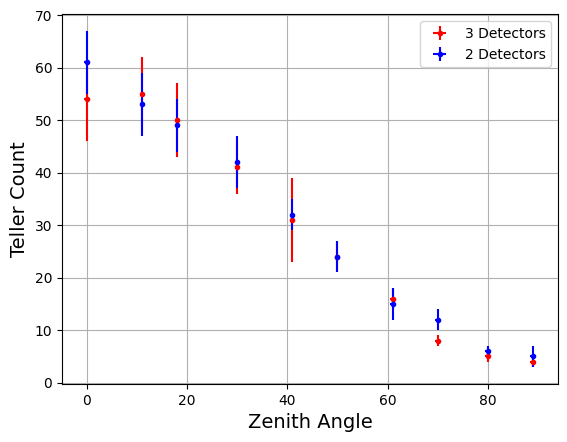

In [47]:
## Show the processed data

# Print it again
#print(anglesList)
#print(tripleList)
#print(doubleList)

# Plot it too
plt.errorbar(anglesList, tripleList[:,0], xerr = 0.5, yerr = tripleList[:,1], fmt = '.',color = 'red' , label = "3 Detectors")
plt.errorbar(anglesList, doubleList[:,0], xerr = 0.5, yerr = doubleList[:,1], fmt = '.',color = 'blue', label = "2 Detectors")
plt.legend()
plt.grid()

plt.xlabel('Zenith Angle', fontdict={'size' : 14})
plt.ylabel('Teller Count', fontdict={'size' : 14})

plt.show()

In [48]:
## Fit the data
import odrpack

# Cos^n fitting def
def fitting_funct(xVal, params: np.ndarray):
    '''Fitting function for the given datapoints'''
    return params[0]*np.power((np.cos(xVal*(np.pi/180))),params[1]) + params[2] 

# TRIPLE
print("Triple:")
popt, _ = scipy.optimize.curve_fit(lambda x,a,b,c: fitting_funct(x,[a,b,c]), anglesList, tripleList[:,0], sigma=tripleList[:,1])

output = odrpack.odr_fit(fitting_funct, anglesList, tripleList[:,0], popt, 
                          weight_x=1/(33.12)**2, weight_y=1/tripleList[:,1]**2,
                          bounds = [0.8*popt,1.15*popt])

print(output.beta)
print(f'Lower bounds: {0.8*popt}')
print(f'Upper bounds: {1.15*popt}')

for i in range(len(output.beta)):
    print(f"Statistical error on parameter {i}: {round(np.sqrt(output.cov_beta[i][i])/(abs(output.beta[i]))*100, 2)}%")

output3 = output

# DOUBLE
print("Double:")
popt, _ = scipy.optimize.curve_fit(lambda x,a,b,c: fitting_funct(x,[a,b,c]), anglesList, doubleList[:,0], sigma=doubleList[:,1])

output = odrpack.odr_fit(fitting_funct, anglesList, doubleList[:,0], popt, 
                          weight_x=1/(33.12)**2, weight_y=1/doubleList[:,1]**2,
                          bounds = [0.8*popt,1.15*popt])

print(output.beta)
print(f'Lower bounds: {0.8*popt}')
print(f'Upper bounds: {1.15*popt}')

for i in range(len(output.beta)):
    print(f"Statistical error on parameter {i}: {round(np.sqrt(output.cov_beta[i][i])/(abs(output.beta[i]))*100, 2)}%")

output2 = output


Triple:
[51.03641567  2.16974859  3.98715224]
Lower bounds: [41.68846571  1.76671556  3.05169968]
Upper bounds: [59.92716946  2.53965362  4.38681828]
Statistical error on parameter 0: 12.23%
Statistical error on parameter 1: 71.56%
Statistical error on parameter 2: 29.4%
Double:
[55.46043409  2.48163855  5.03906154]
Lower bounds: [40.66439121  1.73521072  4.09397548]
Upper bounds: [58.45506236  2.49436541  5.88508975]
Statistical error on parameter 0: 11.02%
Statistical error on parameter 1: 67.57%
Statistical error on parameter 2: 38.93%


C:\Users\Dumitru Andrei\AppData\Local\Temp\ipykernel_1692\1656467319.py:7: RuntimeWarning: invalid value encountered in power
  return params[0]*np.power((np.cos(xVal*(np.pi/180))),params[1]) + params[2]


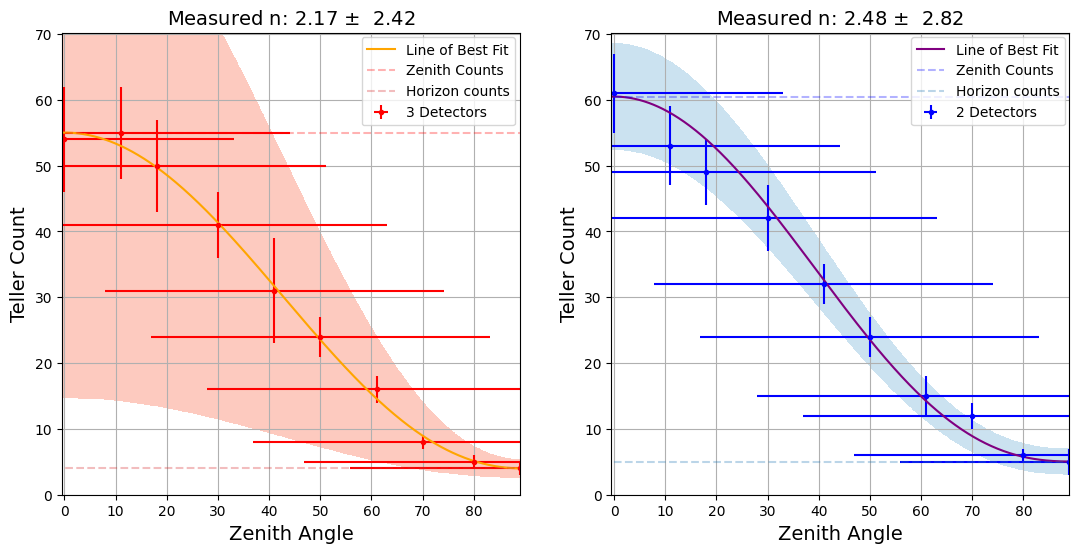

In [58]:
## Plot the data and fit

def errorRound(val, ndigits):
    return round(1 + val*10**ndigits)/(10**ndigits)

# Make figure
fig, ax = plt.subplots(figsize = (13,6), nrows=1, ncols=2)

ax[0].errorbar(anglesList, tripleList[:,0], xerr = 33.12, yerr = tripleList[:,1], fmt = '.',color = 'red' , label = "3 Detectors")
ax[1].errorbar(anglesList, doubleList[:,0], xerr = 33.12, yerr = doubleList[:,1], fmt = '.',color = 'blue', label = "2 Detectors")

plotRange = np.linspace(-0.5,ax[1].get_xlim()[1], 1000)

maxAxY = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1])
ax[0].set_ylim(0, maxAxY)
ax[1].set_ylim(0, maxAxY)

# Triple
ax[0].plot(plotRange, fitting_funct(plotRange, [output3.beta[0], output3.beta[1], output3.beta[2]]), color = 'orange', alpha = 1, label = 'Line of Best Fit')
ax[0].set_xlim([-0.5,max(anglesList)])

xrange = np.linspace(ax[0].get_xlim()[0],ax[0].get_xlim()[1], 1000)
yrange = np.linspace(ax[0].get_ylim()[0],ax[0].get_ylim()[1], 1000)

X, Y = np.meshgrid(xrange, yrange)

Ymin = fitting_funct(X, [output3.beta[0]-output3.cov_beta[0][0], 
                         output3.beta[1], 
                         output3.beta[2]-output3.cov_beta[2][2]])
Ymax = fitting_funct(X, [output3.beta[0]+output3.cov_beta[0][0], 
                         output3.beta[1], 
                         output3.beta[2]+output3.cov_beta[2][2]])

Z = np.logical_and(np.less(Y, Ymax) , np.less(Ymin, Y))

ax[0].contourf(X ,Y ,Z ,levels = [0.99, 1.01], cmap = 'Reds', alpha = 0.35)

ax[0].axhline(output3.beta[0]+output3.beta[2], ax[0].get_xlim()[0], ax[0].get_xlim()[1], linestyle = 'dashed', color = 'red', alpha = 0.3, label='Zenith Counts')
ax[0].axhline(output3.beta[2], ax[0].get_xlim()[0], ax[0].get_xlim()[1], linestyle = 'dashed', color = 'tab:red', alpha = 0.3, label='Horizon counts')

ax[0].set_title(rf'Measured n: {round(output3.beta[1], 2)} $\pm$  {errorRound(output3.cov_beta[1][1],2)}', fontdict={'size' : 14})
ax[0].set_xlabel('Zenith Angle', fontdict={'size' : 14})
ax[0].set_ylabel('Teller Count', fontdict={'size' : 14})
ax[0].legend(bbox_to_anchor=(0.99, 0.99), loc=1, borderaxespad=0)
ax[0].grid()

# Double
ax[1].plot(plotRange, fitting_funct(plotRange, [output2.beta[0], output2.beta[1], output2.beta[2]]), color = 'purple', alpha = 1, label = 'Line of Best Fit')
ax[1].set_xlim([-0.5,max(anglesList)])

xrange = np.linspace(ax[1].get_xlim()[0],ax[1].get_xlim()[1], 1000)
yrange = np.linspace(ax[1].get_ylim()[0],ax[1].get_ylim()[1], 1000)

X, Y = np.meshgrid(xrange, yrange)

Ymin = fitting_funct(X, [output2.beta[0]-np.sqrt(output2.cov_beta[0][0]), 
                         output2.beta[1], 
                         output2.beta[2]-np.sqrt(output2.cov_beta[2][2])])
Ymax = fitting_funct(X, [output2.beta[0]+np.sqrt(output2.cov_beta[0][0]), 
                         output2.beta[1], 
                         output2.beta[2]+np.sqrt(output2.cov_beta[2][2])])

Z = np.logical_and(np.less(Y, Ymax) , np.less(Ymin, Y))

ax[1].contourf(X ,Y ,Z ,levels = [0.99, 1.01], cmap = 'Blues', alpha = 0.35)

ax[1].axhline(output2.beta[0]+output2.beta[2], ax[1].get_xlim()[0], ax[1].get_xlim()[1], linestyle = 'dashed', color = 'blue', alpha = 0.3, label='Zenith Counts')
ax[1].axhline(output2.beta[2], ax[1].get_xlim()[0], ax[1].get_xlim()[1], linestyle = 'dashed', color = 'tab:blue', alpha = 0.3, label='Horizon counts')

ax[1].set_title(rf'Measured n: {round(output2.beta[1], 2)} $\pm$  {errorRound(output2.cov_beta[1][1],2)}', fontdict={'size' : 14})
ax[1].set_xlabel('Zenith Angle', fontdict={'size' : 14})
ax[1].set_ylabel('Teller Count', fontdict={'size' : 14})
ax[1].legend(bbox_to_anchor=(0.99, 0.99), loc=1, borderaxespad=0)
ax[1].grid()





plt.show()


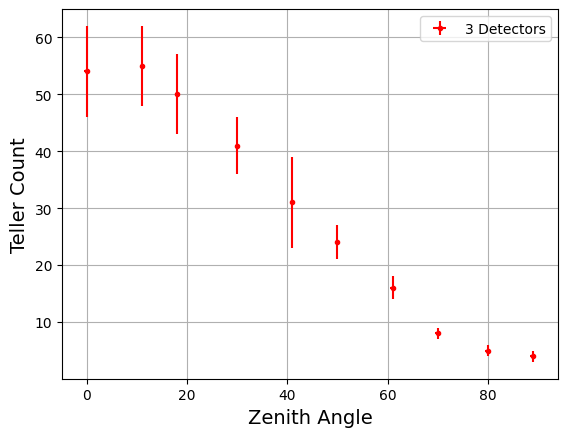

In [ ]:
## Wow that was bad lets try again




plt.errorbar(anglesList, tripleList[:,0], xerr = 0.5, yerr = tripleList[:,1], fmt = '.',color = 'red' , label = "3 Detectors")
plt.legend()
plt.grid()

plt.xlabel('Zenith Angle', fontdict={'size' : 14})
plt.ylabel('Teller Count', fontdict={'size' : 14})

plt.show()